In [1]:
!pip install Faker pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from faker import Faker
import heapq

np.random.seed(42)
random.seed(42)
fake = Faker()
sns.set(style='whitegrid')
print("Setup complete!")

Setup complete!


In [3]:
n_students = 250
names = [fake.name() for _ in range(n_students)]

data = {
    'StudentID': range(1, n_students + 1),
    'Name': names,
    'Gender': np.random.choice(['Male', 'Female'], n_students),
    'Department': np.random.choice(['CSE', 'IT', 'ECE'], n_students, p=[0.4, 0.3, 0.3]),
    'Year': np.random.choice(['1st', '2nd', '3rd'], n_students),
    'Maths': np.random.normal(75, 15, n_students).clip(0, 100).astype(int),
    'Science': np.random.normal(72, 16, n_students).clip(0, 100).astype(int),
    'English': np.random.normal(78, 14, n_students).clip(0, 100).astype(int),
    'Attendance': np.random.normal(85, 10, n_students).clip(50, 100).astype(int),
    'Internal_Marks': np.random.normal(18, 4, n_students).clip(0, 25).astype(int)
}

df = pd.DataFrame(data)
df.to_csv('students.csv', index=False)
print("Dataset generated!")
print(df[['StudentID', 'Name', 'Department']].head())
print(f"Shape: {df.shape}")

Dataset generated!
   StudentID                Name Department
0          1        Kevin Miller         IT
1          2             Amy Lee        ECE
2          3         Scott Logan        ECE
3          4  Katherine Williams        CSE
4          5       Rebekah Kelly         IT
Shape: (250, 10)


In [4]:
mask = np.random.rand(len(df)) < 0.05
df.loc[mask, ['Maths', 'Attendance']] = np.nan

print("Missing values before:\n", df.isnull().sum())

df['Maths'].fillna(df['Maths'].mean(), inplace=True)
df['Attendance'].fillna(df['Attendance'].median(), inplace=True)

df['Total_Marks'] = df[['Maths', 'Science', 'English']].sum(axis=1)
df['Average'] = df['Total_Marks'] / 3
df['Grade'] = pd.cut(df['Average'], bins=[0, 50, 75, 100], labels=['Fail', 'Pass', 'Distinction'])
df['Overall_Score'] = df['Average'] * 0.7 + df['Attendance'] * 0.2 + df['Internal_Marks'] * 0.1

print("Missing values after:\n", df.isnull().sum())
print("\nData cleaning complete!")
print(df[['Grade', 'Overall_Score']].head())

Missing values before:
 StudentID          0
Name               0
Gender             0
Department         0
Year               0
Maths             17
Science            0
English            0
Attendance        17
Internal_Marks     0
dtype: int64
Missing values after:
 StudentID         0
Name              0
Gender            0
Department        0
Year              0
Maths             0
Science           0
English           0
Attendance        0
Internal_Marks    0
Total_Marks       0
Average           0
Grade             0
Overall_Score     0
dtype: int64

Data cleaning complete!
         Grade  Overall_Score
0         Pass      63.200000
1         Pass      59.533333
2         Pass      62.033333
3  Distinction      74.533333
4  Distinction      74.833333


/tmp/ipykernel_12619/447126527.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Maths'].fillna(df['Maths'].mean(), inplace=True)
/tmp/ipykernel_12619/447126527.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [5]:
stats = df[['Maths', 'Science', 'English', 'Attendance', 'Internal_Marks', 'Average']].describe()
print("Descriptive Statistics:")
print(stats.round(2))

Descriptive Statistics:
        Maths  Science  English  Attendance  Internal_Marks  Average
count  250.00   250.00   250.00      250.00          250.00   250.00
mean    75.88    72.04    78.10       83.74           17.39    75.34
std     14.93    15.66    13.98        9.54            3.91     8.44
min     22.00    14.00    43.00       60.00            6.00    49.33
25%     66.25    63.00    69.00       78.00           15.00    69.75
50%     75.94    73.00    78.00       85.00           17.00    76.00
75%     86.00    83.00    90.00       90.00           20.00    81.00
max    100.00   100.00   100.00      100.00           25.00    97.00


In [6]:
def top_performers(df, top_k=10):
    heap = []
    for _, row in df.iterrows():
        score = row['Overall_Score']
        heapq.heappush(heap, (-score, row['StudentID'], row['Name'], row['Department']))
    return heapq.nsmallest(top_k, heap)

top10 = top_performers(df)
print("Top 10 Performers (Heap Priority Queue):")
for i, (score, sid, name, dept) in enumerate(top10, 1):
    print(f"{i}. {name} (ID:{sid}, {dept}): {score:.1f}")


Top 10 Performers (Heap Priority Queue):
1. Michael Harris (ID:96, IT): -87.9
2. Juan Smith (ID:116, ECE): -87.1
3. Austin Brooks (ID:157, CSE): -85.4
4. Donald Taylor (ID:147, ECE): -85.4
5. Jessica Moore (ID:155, ECE): -83.9
6. Andrea Graves (ID:125, ECE): -83.3
7. Mark Lewis (ID:41, ECE): -83.0
8. Kathleen Love (ID:32, IT): -82.8
9. Crystal Smith (ID:97, IT): -82.8
10. Susan Walker (ID:127, CSE): -82.5


In [7]:
def fail_students(df):
    fails = df[df['Grade'] == 'Fail'][['Average', 'StudentID', 'Name', 'Department']].sort_values('Average')
    return fails.head(10)

fails = fail_students(df)
print("Low Performers (Sorted List):")
for _, row in fails.iterrows():
    print(f"{row['Name']} (ID:{row['StudentID']}, {row['Department']}): {row['Average']:.1f}")

Low Performers (Sorted List):
Joshua Brown (ID:35, ECE): 49.3


In [8]:
dept_perf = df.groupby('Department').agg({
    'Average': ['mean', 'std', 'count'],
    'Grade': lambda x: (x == 'Distinction').sum()
}).round(2)
dept_perf.columns = ['Avg_Mean', 'Avg_Std', 'Count', 'Distinctions']
print("Department-wise Performance:")
print(dept_perf)

Department-wise Performance:
            Avg_Mean  Avg_Std  Count  Distinctions
Department                                        
CSE            74.93     7.90    103            55
ECE            76.35     9.77     68            39
IT             75.01     7.92     79            44


In [9]:
gender_comp = df.groupby('Gender')['Average'].agg(['mean', 'std', 'count']).round(2)
year_trend = df.groupby('Year')['Average'].mean().round(2)

print("Gender-wise Comparison:")
print(gender_comp)
print("\nYear-wise Trends:")
print(year_trend)

Gender-wise Comparison:
         mean   std  count
Gender                    
Female  76.43  8.35    124
Male    74.26  8.43    126

Year-wise Trends:
Year
1st    76.15
2nd    75.60
3rd    73.90
Name: Average, dtype: float64


In [10]:
corr = df[['Maths', 'Science', 'English', 'Attendance', 'Internal_Marks', 'Average']].corr()
print("Key Correlations with Average Marks:")
print(corr['Average'].round(2).sort_values(ascending=False))

Key Correlations with Average Marks:
Average           1.00
Science           0.58
English           0.57
Maths             0.55
Internal_Marks    0.04
Attendance       -0.04
Name: Average, dtype: float64


In [11]:
report_data = {
    'Metric': ['Total Students', 'Fail Rate %', 'Distinction %', 'Overall Avg', 'Best Attendance-Marks Corr'],
    'Value': [
        len(df),
        (df['Grade']=='Fail').mean()*100,
        (df['Grade']=='Distinction').mean()*100,
        df['Average'].mean().round(2),
        corr.loc['Attendance', 'Average'].round(2)
    ]
}
report = pd.DataFrame(report_data)
report.to_csv('eda_report.csv', index=False)
print("Summary Report:")
print(report)

Summary Report:
                       Metric   Value
0              Total Students  250.00
1                 Fail Rate %    0.40
2               Distinction %   55.20
3                 Overall Avg   75.34
4  Best Attendance-Marks Corr   -0.04


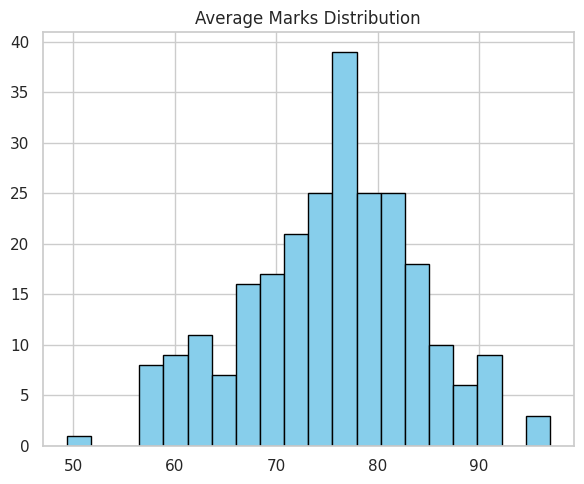

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
df['Average'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Average Marks Distribution')
plt.tight_layout()
plt.show()

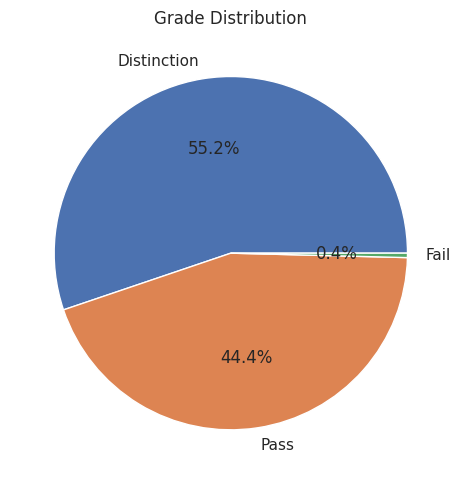

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
df['Grade'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Grade Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

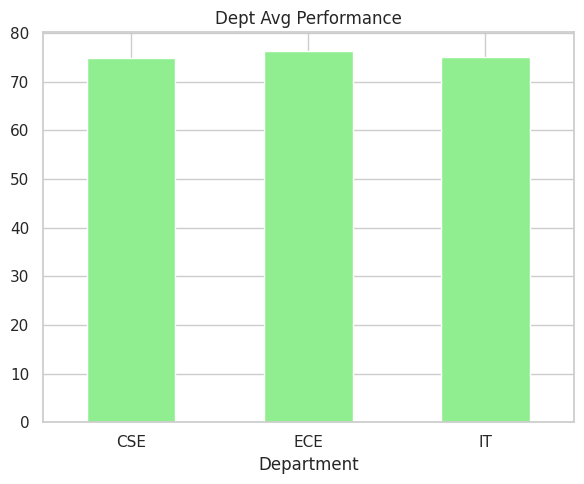

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
dept_perf['Avg_Mean'].plot(kind='bar', color='lightgreen')
plt.title('Dept Avg Performance')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

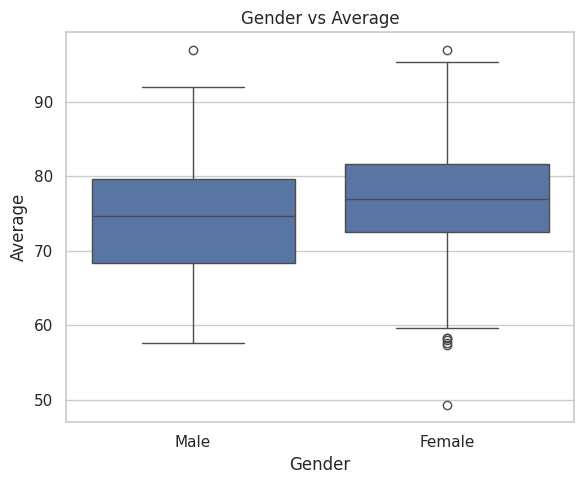

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Gender', y='Average')
plt.title('Gender vs Average')
plt.tight_layout()
plt.show()

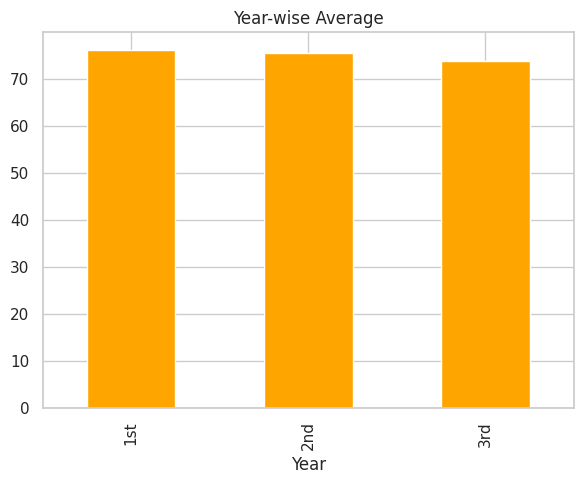

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
year_trend.plot(kind='bar', color='orange')
plt.title('Year-wise Average')
plt.tight_layout()
plt.show()

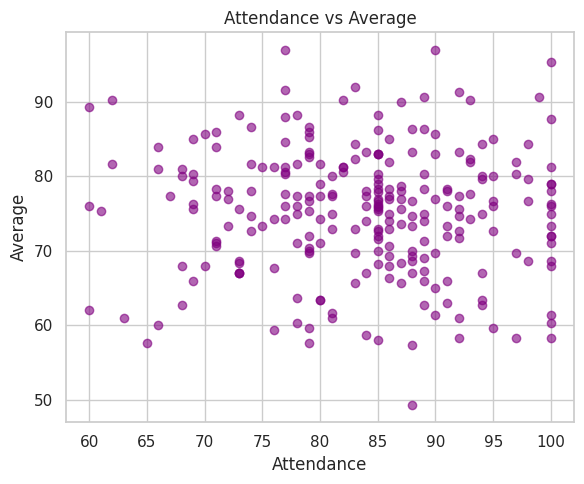

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(df['Attendance'], df['Average'], alpha=0.6, color='purple')
plt.xlabel('Attendance')
plt.ylabel('Average')
plt.title('Attendance vs Average')
plt.tight_layout()
plt.show()

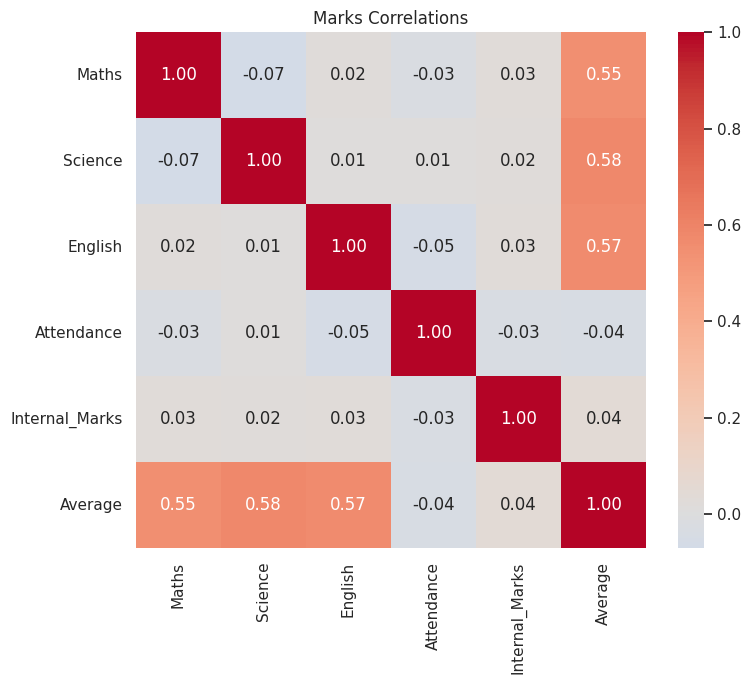

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Marks Correlations')
plt.tight_layout()
plt.show()

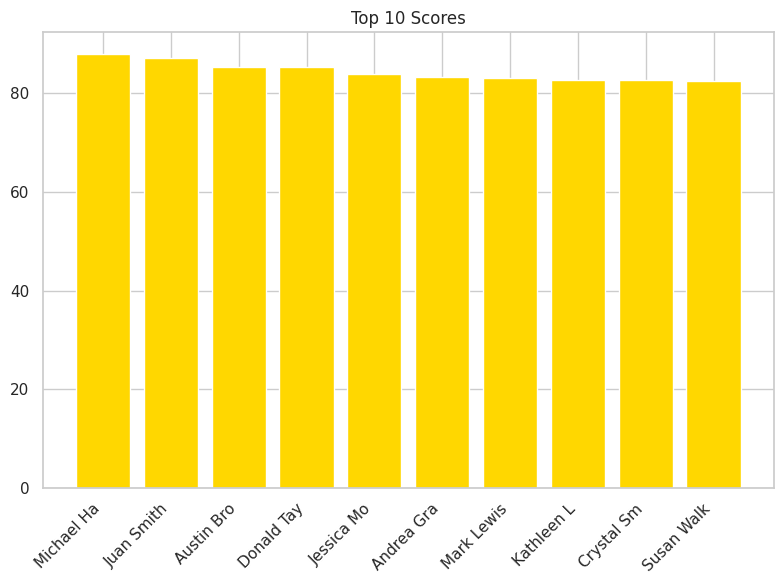

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
top_names = [name[:10] for _,_,name,_ in top10]
top_scores = [-s for s,_,_,_ in top10]
plt.bar(range(len(top_names)), top_scores, color='gold')
plt.title('Top 10 Scores')
plt.xticks(range(len(top_names)), top_names, rotation=45, ha='right')
plt.tight_layout()
plt.show()